# What the model actually sees, and where it actually fails

Two halves:

1. **Augmentation** — the images as they reach the loss, not as they sit on disk.
2. **Worst predictions** — the images the best model does worst on, and why.

Written up in `docs/pipeline-and-data-audit.md`. This notebook is the version you can look at.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import cv2, numpy as np, yaml
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 72  # keeps the saved notebook a sane size in git

# Inference on CPU so this notebook never fights a training run for the GPU.
DEVICE = "cpu"
BEST_RUN = "cond3b_gated_yolo11n"
print(ROOT)

C:\Users\Ridvan\Desktop\tez\MasterRepoistory


## Part 1 — Augmentation

Build the **exact** training dataloader: same config, same subset list, same transforms.

In [2]:
from ultralytics.cfg import get_cfg
from ultralytics.data import build_yolo_dataset
from ultralytics.utils import DEFAULT_CFG

from src.utils.config import load_run_config


def training_dataset(config_name, imgsz=640):
    """The dataset object the trainer itself builds, for any run config."""
    cfg = load_run_config(str(ROOT / "configs" / "train" / config_name))
    sub = cfg.dataset_root / "subsets" / f"{cfg.run_name}.yaml"
    spec = yaml.safe_load(Path(sub if sub.exists() else cfg.data_yaml).read_text(encoding="utf-8"))
    names = spec.get("names", {})
    data = {"train": spec["train"], "val": spec.get("val"), "names": names,
            "nc": len(names), "path": Path(spec["path"]), "channels": 3}
    ov = get_cfg(DEFAULT_CFG, dict(cfg.train))
    ov.imgsz, ov.mode = imgsz, "train"
    ds = build_yolo_dataset(ov, str(spec["train"]), 16, data, mode="train", rect=False)
    return ds, ov, names


ds, ov, NAMES = training_dataset("cond3b_gated_yolo11n.yaml")
print(f"{len(ds)} training images")
for k in ("mosaic", "close_mosaic", "hsv_h", "hsv_s", "hsv_v", "scale", "translate",
          "fliplr", "erasing", "mixup", "copy_paste"):
    print(f"  {k:<14} {getattr(ov, k)}")

train: Fast image access  (ping: 0.10.0 ms, read: 1571.9726.1 MB/s, size: 191.2 KB)


train: Scanning C:\Users\Ridvan\Desktop\tez\MasterRepoistory\data\dior_hbb_full\union3b\labels\train.cache... 5862 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5862/5862  0.0s

5862 training images
  mosaic         1.0
  close_mosaic   10
  hsv_h          0.015
  hsv_s          0.7
  hsv_v          0.4
  scale          0.5
  translate      0.1
  fliplr         0.5
  erasing        0.4
  mixup          0.0
  copy_paste     0.0


### The augmented images, exactly as the loss receives them

The title of each panel is the condition the **gate is supervised with** — read from
`im_file`. Look at whether the picture agrees with the title.

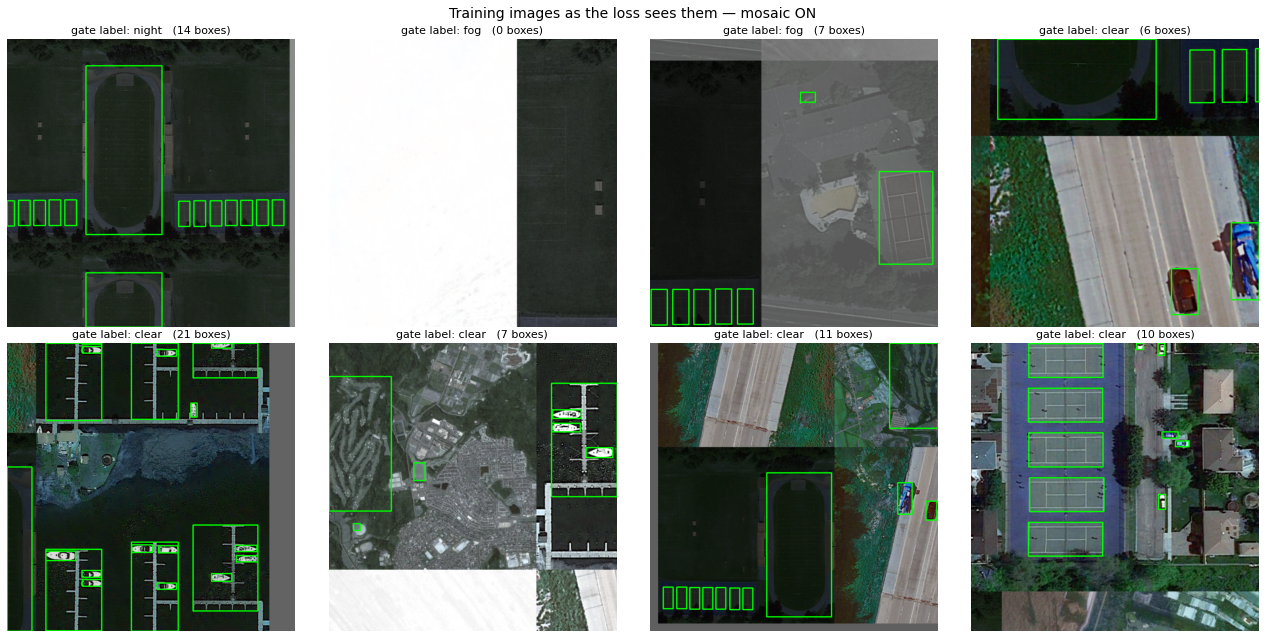

In [3]:
from src.models.moe2 import CONDITION_ALIASES, CONDITION_ORDER


def condition_of(path):
    for tok in Path(str(path)).stem.lower().split("_"):
        tok = CONDITION_ALIASES.get(tok, tok)
        if tok in CONDITION_ORDER:
            return tok
    return "?"


def draw(sample):
    """One dataset sample -> RGB image with its (augmented) boxes drawn."""
    im = sample["img"].numpy().transpose(1, 2, 0)[:, :, ::-1].copy()  # CHW BGR -> HWC RGB
    h, w = im.shape[:2]
    for (cx, cy, bw, bh) in sample["bboxes"].numpy():
        cv2.rectangle(im, (int((cx - bw / 2) * w), int((cy - bh / 2) * h)),
                      (int((cx + bw / 2) * w), int((cy + bh / 2) * h)), (0, 255, 0), 2)
    return im


rng = np.random.default_rng(0)
idx = rng.integers(0, len(ds), 8)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, i in zip(axes.ravel(), idx):
    s = ds[int(i)]
    ax.imshow(draw(s))
    ax.set_title(f"gate label: {condition_of(s['im_file'])}   ({len(s['bboxes'])} boxes)", fontsize=11)
    ax.axis("off")
fig.suptitle("Training images as the loss sees them — mosaic ON", fontsize=14)
plt.tight_layout(); plt.show()

### The problem, measured

Mosaic glues four random images together and keeps only the **first** one's path
(`ultralytics/data/augment.py:759` — *"File path of the first image in the mosaic"*).
Our gate label comes from that path. So: how often do the four tiles actually share a condition?

Mosaic active: p=1.0, n=4 images per canvas
  mosaics whose tiles are NOT all one condition : 96.0%
  mean fraction of canvas matching its label     : 0.501

  -> the gate is given a one-hot label for a canvas that is
     on average 50% some other condition.


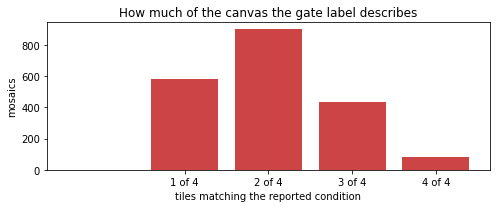

In [4]:
def find(t, name, out=None):
    """Mosaic lives in a NESTED Compose, so a flat scan of .transforms misses it."""
    out = [] if out is None else out
    if type(t).__name__ == name:
        out.append(t)
    for attr in ("transforms", "tlist"):
        for c in getattr(t, attr, []) or []:
            find(c, name, out)
    return out


mosaic = find(ds.transforms, "Mosaic")
if not mosaic:
    print("mosaic is OFF for this config")
else:
    m = mosaic[0]
    print(f"Mosaic active: p={m.p}, n={m.n} images per canvas")
    # Mosaic draws its 3 extra tiles from `dataset.buffer`, a rolling pool of
    # recently loaded images (up to 1000 in steady-state training). Sampling
    # uniformly reproduces that regime without having to warm the buffer.
    rng = np.random.default_rng(0)
    fracs = []
    for _ in range(2000):
        conds = [condition_of(ds.im_files[j])
                 for j in rng.integers(0, len(ds), m.n)]
        fracs.append(sum(c == conds[0] for c in conds) / len(conds))
    fracs = np.array(fracs)
    print(f"  mosaics whose tiles are NOT all one condition : {100 * (fracs < 1).mean():.1f}%")
    print(f"  mean fraction of canvas matching its label     : {fracs.mean():.3f}")
    print(f"\n  -> the gate is given a one-hot label for a canvas that is")
    print(f"     on average {100 * (1 - fracs.mean()):.0f}% some other condition.")
    plt.figure(figsize=(7, 3))
    plt.hist(fracs, bins=np.arange(0, 1.3, 0.25) - 0.125, rwidth=0.8, color="#c44")
    plt.xticks([0.25, 0.5, 0.75, 1.0], ["1 of 4", "2 of 4", "3 of 4", "4 of 4"])
    plt.xlabel("tiles matching the reported condition"); plt.ylabel("mosaics")
    plt.title("How much of the canvas the gate label describes")
    plt.tight_layout(); plt.show()

### Mosaic off — what the fix looks like

`cond3d_nomosaic_yolo11n` is the same run with `mosaic: 0.0`, `hsv_v: 0.15`, `hsv_s: 0.3`.
Now one image per canvas, so the label describes the whole picture.

train: Fast image access  (ping: 0.10.0 ms, read: 1416.5556.4 MB/s, size: 295.1 KB)


train: Scanning C:\Users\Ridvan\Desktop\tez\MasterRepoistory\data\dior_hbb_full\union3b\labels\train.cache... 5862 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5862/5862  0.0s

mosaic=0.0  hsv_v=0.15  hsv_s=0.3


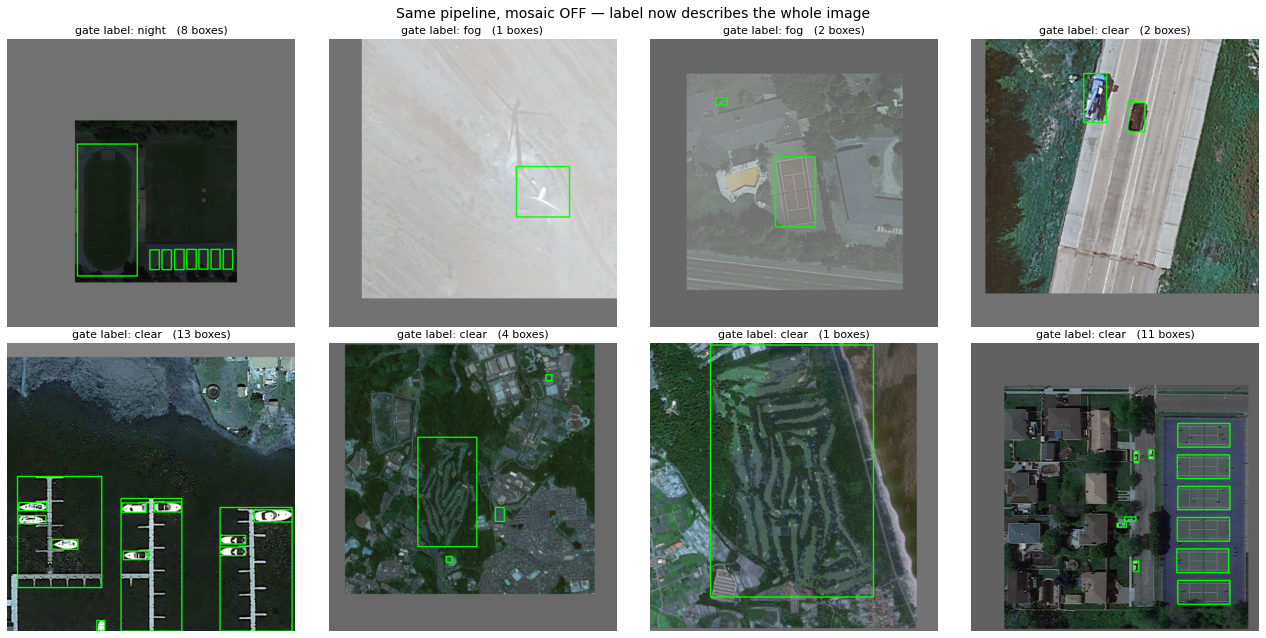

In [5]:
ds_off, ov_off, _ = training_dataset("cond3d_nomosaic_yolo11n.yaml")
print(f"mosaic={ov_off.mosaic}  hsv_v={ov_off.hsv_v}  hsv_s={ov_off.hsv_s}")

rng = np.random.default_rng(0)
idx = rng.integers(0, len(ds_off), 8)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, i in zip(axes.ravel(), idx):
    s = ds_off[int(i)]
    ax.imshow(draw(s))
    ax.set_title(f"gate label: {condition_of(s['im_file'])}   ({len(s['bboxes'])} boxes)", fontsize=11)
    ax.axis("off")
fig.suptitle("Same pipeline, mosaic OFF — label now describes the whole image", fontsize=14)
plt.tight_layout(); plt.show()

### The colour jitter, on its own

`hsv_v=0.4` randomises brightness and `hsv_s=0.7` randomises saturation.
Brightness is what *defines* night; desaturation is the signature of haze.
Six random draws of the same clear image:

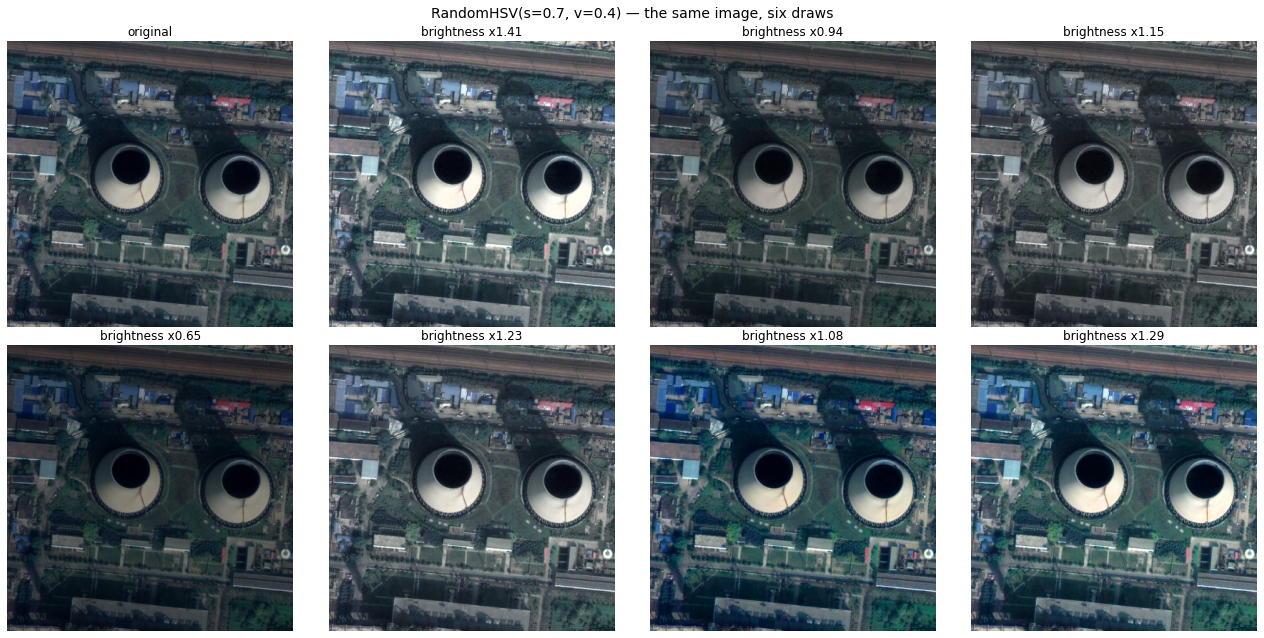

In [6]:
from ultralytics.data.augment import RandomHSV

src = cv2.imread(ds.im_files[0])
src = cv2.resize(src, (400, 400))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes.ravel()[0].imshow(src[:, :, ::-1]); axes.ravel()[0].set_title("original"); axes.ravel()[0].axis("off")

hsv = RandomHSV(hgain=ov.hsv_h, sgain=ov.hsv_s, vgain=ov.hsv_v)
for ax in axes.ravel()[1:]:
    lab = {"img": src.copy()}
    hsv(lab)
    v = lab["img"].astype(np.float32).mean() / src.astype(np.float32).mean()
    ax.imshow(lab["img"][:, :, ::-1])
    ax.set_title(f"brightness x{v:.2f}"); ax.axis("off")
fig.suptitle(f"RandomHSV(s={ov.hsv_s}, v={ov.hsv_v}) — the same image, six draws", fontsize=14)
plt.tight_layout(); plt.show()

### Does the jitter actually erase the condition signal?

Measure it rather than assume it: the HSV channel means of each condition, and the range
each one spans once `hsv_v=0.4` and `hsv_s=0.7` are applied.

                        brightness V                saturation S
            mean        after jitter    mean        after jitter
clear      112.9            68 - 158    48.5             15 - 82
fog2       172.8           104 - 242     8.6              3 - 15
night       35.8             21 - 50    66.1            20 - 112


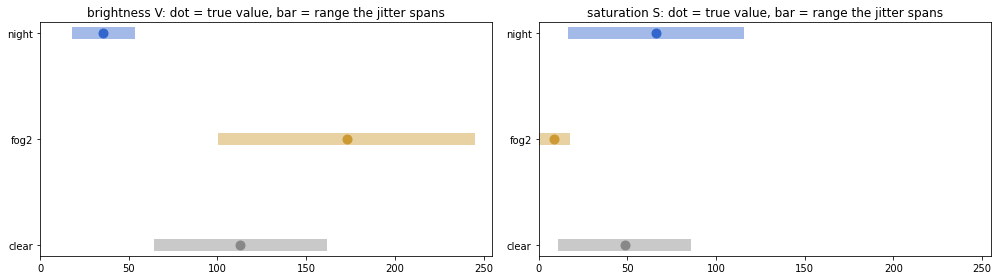

Where the bars overlap, the jitter has made the two conditions
indistinguishable on that channel.


In [7]:
from src.utils.paths import dataset_root

root = dataset_root("detect", "full")
rng = np.random.default_rng(0)
stats = {}
for cond in ["clear", "fog2", "night"]:
    fs = sorted((root / cond / "images" / "val").iterdir())
    fs = [fs[i] for i in rng.choice(len(fs), 120, replace=False)]
    hs = [cv2.cvtColor(cv2.imread(str(f)), cv2.COLOR_BGR2HSV) for f in fs]
    stats[cond] = (np.mean([h[:, :, 2].mean() for h in hs]),
                   np.mean([h[:, :, 1].mean() for h in hs]))

print(f"{'':8s}{'brightness V':>28s}{'saturation S':>28s}")
print(f"{'':8s}{'mean':>8s}{'after jitter':>20s}{'mean':>8s}{'after jitter':>20s}")
for c, (v, s) in stats.items():
    print(f"{c:8s}{v:8.1f}{f'{v*(1-ov.hsv_v):.0f} - {v*(1+ov.hsv_v):.0f}':>20s}"
          f"{s:8.1f}{f'{s*(1-ov.hsv_s):.0f} - {min(s*(1+ov.hsv_s), 255):.0f}':>20s}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (ch, gain, idx) in zip(axes, [("brightness V", ov.hsv_v, 0), ("saturation S", ov.hsv_s, 1)]):
    for y, (c, col) in enumerate(zip(stats, ["#888", "#c93", "#36c"])):
        m = stats[c][idx]
        ax.plot([m * (1 - gain), min(m * (1 + gain), 255)], [y, y], lw=12, color=col, alpha=0.45)
        ax.plot(m, y, "o", color=col, ms=9)
    ax.set_yticks(range(3)); ax.set_yticklabels(list(stats))
    ax.set_title(f"{ch}: dot = true value, bar = range the jitter spans")
    ax.set_xlim(0, 255)
plt.tight_layout(); plt.show()
print("Where the bars overlap, the jitter has made the two conditions")
print("indistinguishable on that channel.")

### For contrast: the three conditions we are trying to tell apart

Same DIOR scene, rendered three ways. Compare the size of *this* difference to the
size of the jitter above.

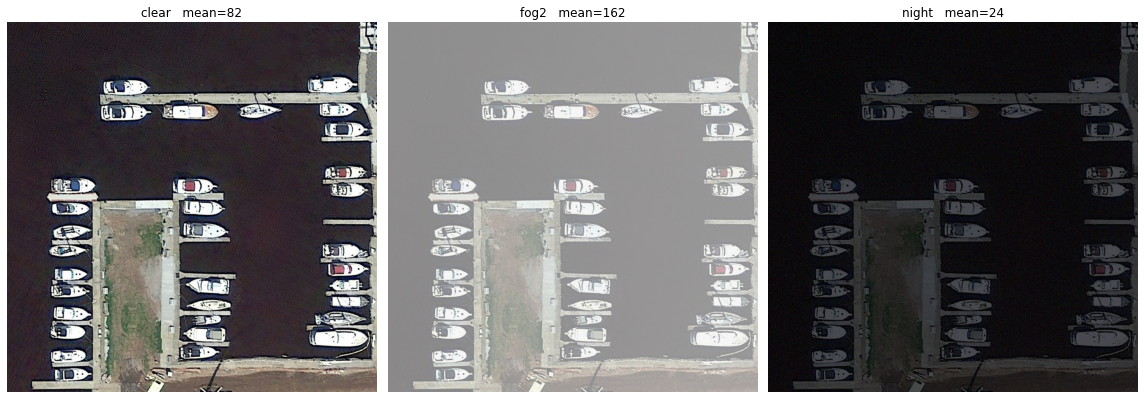

In [8]:
from src.utils.paths import dataset_root

root = dataset_root("detect", "full")
stem = sorted(p.stem.split("_", 1)[-1] for p in (root / "clear" / "images" / "val").iterdir())[40]
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, cond in zip(axes, ["clear", "fog2", "night"]):
    hit = next((root / cond / "images" / "val").glob(f"*{stem}.*"), None)
    im = cv2.imread(str(hit))
    ax.imshow(im[:, :, ::-1])
    ax.set_title(f"{cond}   mean={im.mean():.0f}"); ax.axis("off")
plt.tight_layout(); plt.show()

---
## Part 2 — Worst predictions

Score every val image by per-image F1 (greedy IoU-0.5 matching), then look at the tail.

In [9]:
from ultralytics import YOLO

from src.utils.paths import OUTPUT_DIR

model = YOLO(str(OUTPUT_DIR / "runs" / BEST_RUN / "weights" / "best.pt"))
names = model.model.names

COND = "union3b"
img_dir = root / COND / "images" / "val"
lbl_dir = root / COND / "labels" / "val"
images = sorted(p for p in img_dir.iterdir() if p.suffix.lower() in {".jpg", ".png"})
rng = np.random.default_rng(0)
images = [images[i] for i in rng.choice(len(images), min(300, len(images)), replace=False)]
print(f"scoring {len(images)} images with {BEST_RUN} on {DEVICE}")

scoring 300 images with cond3b_gated_yolo11n on cpu


In [10]:
from collections import Counter


def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return inter / np.maximum(aa[:, None] + bb[None, :] - inter, 1e-9)


def load_gt(stem, h, w):
    p = lbl_dir / f"{stem}.txt"
    out = []
    for line in (p.read_text(encoding="utf-8").splitlines() if p.exists() else []):
        if line.strip():
            f = line.split(); c = int(f[0]); cx, cy, bw, bh = (float(v) for v in f[1:5])
            out.append([c, (cx - bw / 2) * w, (cy - bh / 2) * h, (cx + bw / 2) * w, (cy + bh / 2) * h])
    return np.array(out, dtype=float) if out else np.zeros((0, 5))


BANDS = ["<8px", "8-16px", "16-32px", "32-64px", ">=64px"]


def band_of(box):
    side = np.sqrt(max((box[3] - box[1]) * (box[4] - box[2]), 0))
    return BANDS[0] if side < 8 else BANDS[1] if side < 16 else \
        BANDS[2] if side < 32 else BANDS[3] if side < 64 else BANDS[4]


rows, gt_size, fn_size, gt_cls, fn_cls = [], Counter(), Counter(), Counter(), Counter()
n_conf = n_blind = 0
for i in range(0, len(images), 16):
    chunk = images[i:i + 16]
    for p, r in zip(chunk, model.predict([str(x) for x in chunk], imgsz=640, conf=0.25,
                                         verbose=False, device=DEVICE)):
        h, w = r.orig_shape
        gt = load_gt(p.stem, h, w)
        b = r.boxes
        pred = (np.concatenate([b.cls.cpu().numpy()[:, None], b.xyxy.cpu().numpy()], 1)
                if b is not None and len(b) else np.zeros((0, 5)))
        if len(pred):
            pred = pred[np.argsort(-b.conf.cpu().numpy())]

        M = iou_matrix(pred[:, 1:], gt[:, 1:]) if len(gt) and len(pred) else None
        matched, tp = set(), 0
        if M is not None:
            for pi in range(len(pred)):
                cand = [(M[pi, gj], gj) for gj in range(len(gt))
                        if gj not in matched and gt[gj, 0] == pred[pi, 0]]
                if cand:
                    best, gj = max(cand)
                    if best >= 0.5:
                        matched.add(gj); tp += 1

        for gj in range(len(gt)):
            gt_size[band_of(gt[gj])] += 1; gt_cls[int(gt[gj, 0])] += 1
            if gj not in matched:
                fn_size[band_of(gt[gj])] += 1; fn_cls[int(gt[gj, 0])] += 1
                # was ANY box, of any class, sitting on it?
                if M is not None and len(pred) and M[:, gj].max() >= 0.5:
                    n_conf += 1
                else:
                    n_blind += 1

        prec, rec = tp / max(len(pred), 1), tp / max(len(gt), 1)
        rows.append({"image": p, "n_gt": len(gt), "n_pred": len(pred), "tp": tp,
                     "fn": len(gt) - len(matched), "fp": len(pred) - tp,
                     "f1": 2 * prec * rec / max(prec + rec, 1e-9),
                     "cond": condition_of(p)})

rows.sort(key=lambda r: (r["f1"], -r["n_gt"]))
tot_gt, tot_fn = sum(gt_cls.values()), sum(fn_cls.values())
print(f"{tot_gt} objects | {tot_fn} missed ({100 * tot_fn / tot_gt:.1f}%)")
print(f"of those misses: {n_blind} never detected ({100 * n_blind / tot_fn:.1f}%), "
      f"{n_conf} detected under the wrong class ({100 * n_conf / tot_fn:.1f}%)")

1523 objects | 358 missed (23.5%)
of those misses: 351 never detected (98.0%), 7 detected under the wrong class (2.0%)


### Miss rate by object size — the cliff

This is the largest single effect in the project.

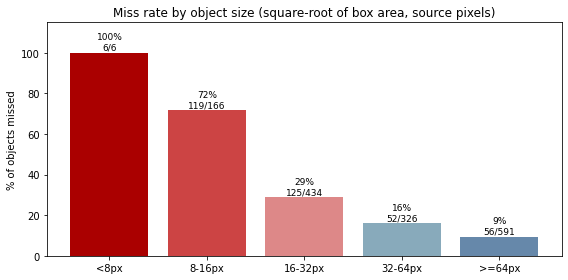

In [11]:
rates = [100 * fn_size[b] / max(gt_size[b], 1) for b in BANDS]
plt.figure(figsize=(8, 4))
bars = plt.bar(BANDS, rates, color=["#a00", "#c44", "#d88", "#8ab", "#68a"])
for b, r, n in zip(bars, rates, BANDS):
    plt.text(b.get_x() + b.get_width() / 2, r + 1.5,
             f"{r:.0f}%\n{fn_size[n]}/{gt_size[n]}", ha="center", fontsize=9)
plt.ylabel("% of objects missed"); plt.ylim(0, 115)
plt.title("Miss rate by object size (square-root of box area, source pixels)")
plt.tight_layout(); plt.show()

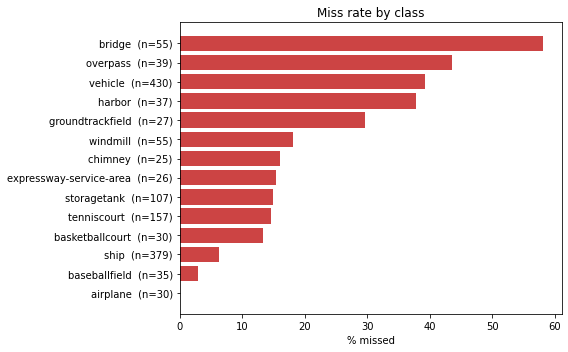

In [12]:
worst = sorted(((100 * fn_cls[c] / g, names[c], g) for c, g in gt_cls.items() if g >= 25),
               reverse=True)
plt.figure(figsize=(8, 5))
plt.barh([f"{n}  (n={g})" for _, n, g in worst][::-1], [r for r, _, _ in worst][::-1],
         color="#c44")
plt.xlabel("% missed"); plt.title("Miss rate by class")
plt.tight_layout(); plt.show()

### The worst images

**Green = ground truth. Red = prediction.**

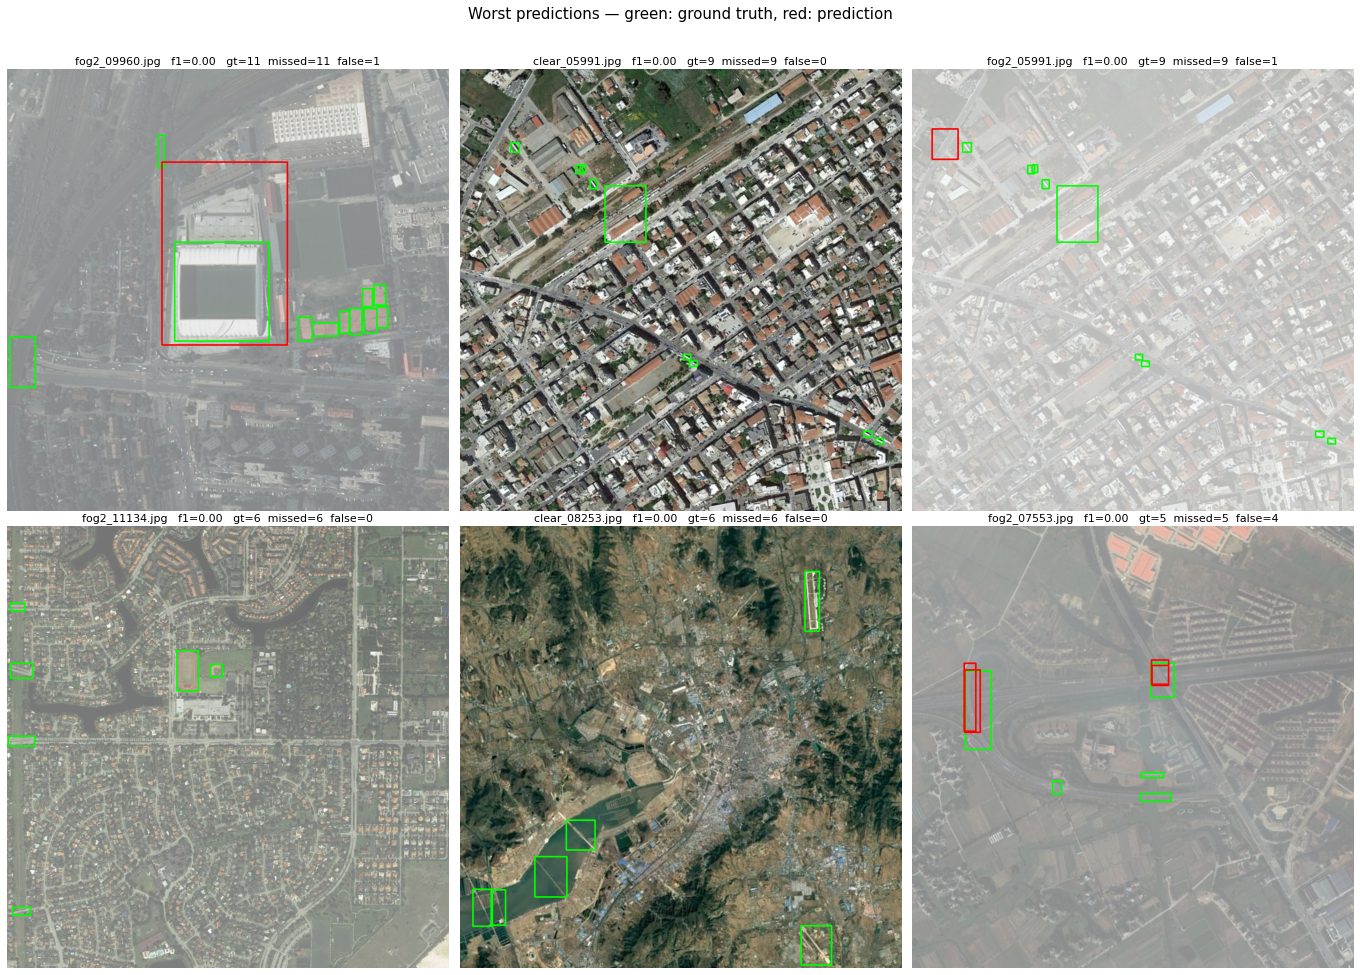

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(19, 14))
for ax, r in zip(axes.ravel(), rows[:6]):
    p = r["image"]
    im = cv2.imread(str(p)); h, w = im.shape[:2]
    for g in load_gt(p.stem, h, w):
        cv2.rectangle(im, (int(g[1]), int(g[2])), (int(g[3]), int(g[4])), (0, 255, 0), 2)
    pr = model.predict(str(p), imgsz=640, conf=0.25, verbose=False, device=DEVICE)[0]
    if pr.boxes is not None:
        for b in pr.boxes.xyxy.cpu().numpy():
            cv2.rectangle(im, (int(b[0]), int(b[1])), (int(b[2]), int(b[3])), (0, 0, 255), 2)
    ax.imshow(im[:, :, ::-1]); ax.axis("off")
    ax.set_title(f"{p.name}   f1={r['f1']:.2f}   gt={r['n_gt']}  missed={r['fn']}  false={r['fp']}",
                 fontsize=11)
fig.suptitle("Worst predictions — green: ground truth, red: prediction", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

### Is it the degraded conditions?

No — this is the control that says the failure is about object size, not about fog or night.

In [14]:
from collections import defaultdict

by_cond = defaultdict(list)
for r in rows:
    by_cond[r["cond"]].append(r["f1"])
for k in sorted(by_cond):
    print(f"  {k:<8} mean per-image F1 = {np.mean(by_cond[k]):.3f}   (n={len(by_cond[k])})")

  clear    mean per-image F1 = 0.757   (n=90)
  fog      mean per-image F1 = 0.730   (n=100)
  night    mean per-image F1 = 0.798   (n=110)


---
## What to take away

1. **Mosaic corrupts the gate label.** 97% of training canvases mix conditions; the label
   describes ~50% of the picture. The gate's measured confidence (0.500) matches that
   fraction (0.506) — it was fitting its data correctly, on a broken label.
2. **`hsv_v` and `hsv_s` randomise the very signals that define night and haze.**
3. **The detector's dominant error is object size, not condition and not class.**
   100% miss under 8 px, 64% under 16 px, ~10% above 32 px. Only ~2% of misses are class
   confusion; the rest produce no box at all — lowering `conf` to 0.01 costs 13× the false
   positives and recovers under a third of them.

Full write-up with the threshold and resolution sweeps: `docs/pipeline-and-data-audit.md`.